In [13]:
import pandas as pd 
import logging 
import duckdb 
import matplotlib.pyplot as plt
 
logging.basicConfig(
    level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s',
    filename='pr_chart.log'
)
logger = logging.getLogger(__name__)

In [2]:
### load duckdb table into pandas dfs 
con = None 
try: 
    # create and verify connection 
    con = duckdb.connect(database='project1.db', read_only=False) 
    logger.info("Connected to duckdb instance.") 

    # inserting tables 
    df = con.execute(f"""
        SELECT * FROM combined_df;
    """).fetchdf()
    
    logger.info("combined_df loaded into pandas dataframes")

except Exception as e:
    logger.error(f"An error occurred: {e}")

finally:
    if con:
        con.close()
        logger.info("Duckdb connection closed.")

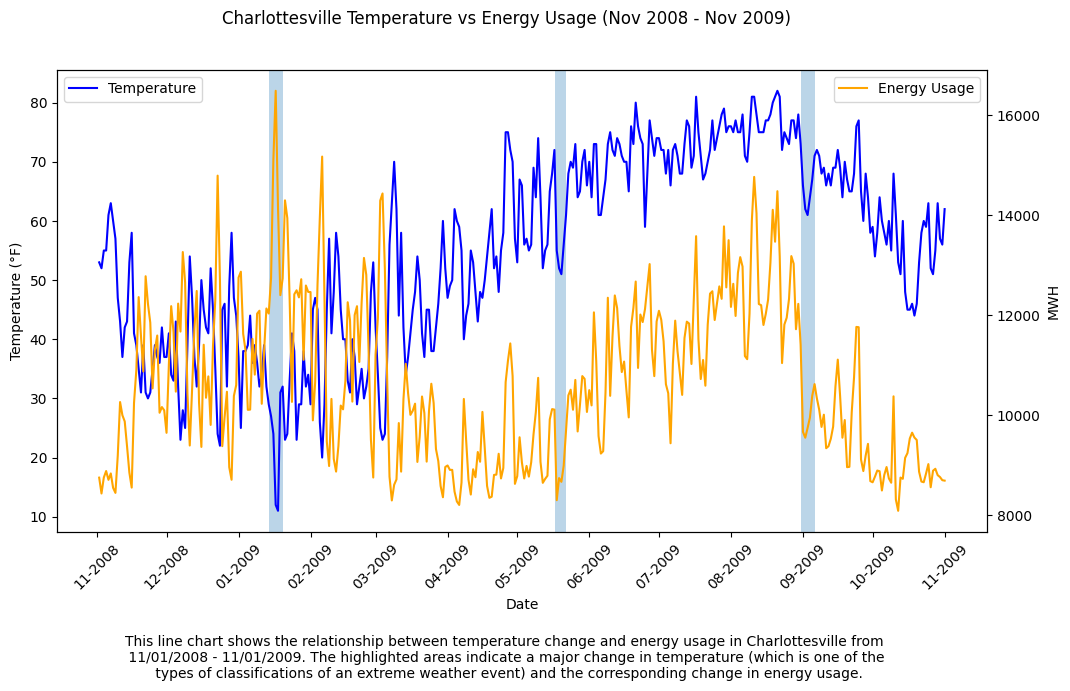

In [68]:
# filtering for Charlottesville, between 11/1/2008 and 11/1/2009 
cdf = df[df['STATION'] == 'Charlottesville'].copy() 
cdf = cdf[cdf['DATE'] > "2008-11-01"]
cdf = cdf[cdf['DATE'] < "2009-11-01"]

# create figure and dual axis 
fig, ax1 = plt.subplots(figsize=(12,6))
ax2 = ax1.twinx()

# plot temperature in blue and energy usage in orange
ax1.plot(cdf['DATE'], cdf['DailyAverageDryBulbTemperature'], linestyle='solid', color='blue', label='Temperature')
ax2.plot(cdf['DATE'], cdf['DOM_MW'], linestyle='solid', color='orange', label='Energy Usage')

# add highlight where major temperature and then energy change occurred 
ax1.axvspan(pd.to_datetime("2009-01-14"), pd.to_datetime("2009-01-20"), alpha=0.3)
ax1.axvspan(pd.to_datetime("2009-05-17"), pd.to_datetime("2009-05-22"), alpha=0.3)
ax1.axvspan(pd.to_datetime("2009-08-31"), pd.to_datetime("2009-09-06"), alpha=0.3)

# set y labels on each axis 
ax1.set_ylabel('Temperature (°F)') 
ax2.set_ylabel('MWH')

# add legends for each line 
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# create xaxis ticks for each month and display as month-year
ticks=pd.to_datetime([
    '2008-11-01', '2008-12-01', "2009-01-01", "2009-02-01", "2009-03-01", "2009-04-01", "2009-05-01",
    "2009-06-01", "2009-07-01", "2009-08-01", "2009-09-01", "2009-10-01", "2009-11-01"])
ax1.set_xticks(ticks)
ax1.set_xticklabels(ticks.strftime('%m-%Y'), rotation=45)
ax1.set_xlabel('Date')

# create title 
plt.suptitle('Charlottesville Temperature vs Energy Usage (Nov 2008 - Nov 2009)')

# create caption 
plt.figtext(0.5, -0.13, 'This line chart shows the relationship between temperature change and energy usage in Charlottesville from \n 11/01/2008 - 11/01/2009. The highlighted areas indicate a major change in temperature (which is one of the \n types of classifications of an extreme weather event) and the corresponding change in energy usage.', 
            wrap=True, horizontalalignment='center', fontsize=10)

# save as png 
plt.savefig('pr_chart.png', bbox_inches='tight')

plt.show() 